# 🌳 Yggdrasil — Segmentação de LGD

Tutorial do subpacote `yggdrasil.credit_risk.lgd`. Constrói uma régua de **LGD** a partir de uma base sintética, mostra as folhas, a árvore, o `predict` e a régua em PySpark.

**Instalação** (na raiz do repositório):
```bash
pip install -e ".[ui]"   # núcleo + interface interativa
```
> No Databricks: `%pip install -e ".[ui]"` (ou `%pip install optbinning`) num cluster interativo DBR 13.0+ LTS.

In [10]:
import numpy as np
import pandas as pd
from yggdrasil.credit_risk.lgd import SequentialLGDSegmenter

# --- base sintética: LGD de financiamento de veículo, com DES, OOT e ESTABILIDADE ---
# A população de LTV MIGRA ao longo das safras (dt_ref) — é o que faz o PSI subir nas
# safras mais recentes (OOT e, principalmente, ESTABILIDADE).
rng = np.random.default_rng(42)
def gera(n, t0='2022-01-01'):
    dt_ref = pd.to_datetime(t0) + pd.to_timedelta(rng.integers(0, 365, n), unit='D')
    midx = (dt_ref.year.values - 2022) * 12 + (dt_ref.month.values - 1)   # nº do mês desde jan/2022
    ltv = rng.beta(2.5, 3, n) * 1.4 + 0.3 + 0.008 * midx     # LTV migra ~0,008/mês (drift de população)
    ltv[rng.random(n) < 0.06] = np.nan                       # ~6% de LTV faltante
    atraso = rng.integers(30, 720, n)
    gar = rng.choice(['alienação','aval','fiança','sem garantia'], n, p=[.5,.22,.18,.1])
    lg = {'alienação':0.0,'aval':0.10,'fiança':0.14,'sem garantia':0.28}
    base = (0.05 + 0.45*np.clip(np.nan_to_num(ltv-0.5, nan=0.35), 0, 1)
            + 0.10*(atraso>360) + np.array([lg[g] for g in gar]))
    return pd.DataFrame({'ltv': ltv, 'dias_atraso': atraso, 'garantia': gar, 'dt_ref': dt_ref,
                         'lgd': np.clip(base + rng.normal(0, 0.07, n), 0, 1)})

des = gera(6000, t0='2022-01-01'); des['amostra'] = 'DES'           # desenvolvimento (referência PSI)
oot = gera(2500, t0='2023-07-01'); oot['amostra'] = 'OOT'           # out-of-time (com LGD realizado)
# ESTABILIDADE: público de LGD MAIS RECENTE, só para validar o modelo — SEM variável resposta.
#   Ainda não há LGD realizado para essa safra; serve apenas para PSI/estabilidade da régua e
#   das variáveis de entrada (entra no PSI, mas não tem média de LGD nem entra nas métricas).
est = gera(1800, t0='2024-01-01'); est['amostra'] = 'ESTABILIDADE'
est['lgd'] = np.nan

df = pd.concat([des, oot, est], ignore_index=True)
# resumo por amostra: ESTABILIDADE fica com LGD médio NaN (sem target), mas com volumetria
df.groupby('amostra', sort=False)['lgd'].agg(n='size', lgd_medio='mean')

,n,lgd_medio
amostra,,
DES,6000,0.389511
OOT,2500,0.448687
ESTABILIDADE,1800,NaN


## LGD ao longo do tempo (safra `dt_ref`)
Análise temporal da base: **LGD médio por mês de referência**. DES (2022) e OOT (2023–24) têm LGD realizado; **ESTABILIDADE** (público mais recente) ainda **não tem target**, então não entra nesta curva — aparece só no PSI. Como a população de LTV migra ao longo das safras, o LGD realizado sobe no tempo.

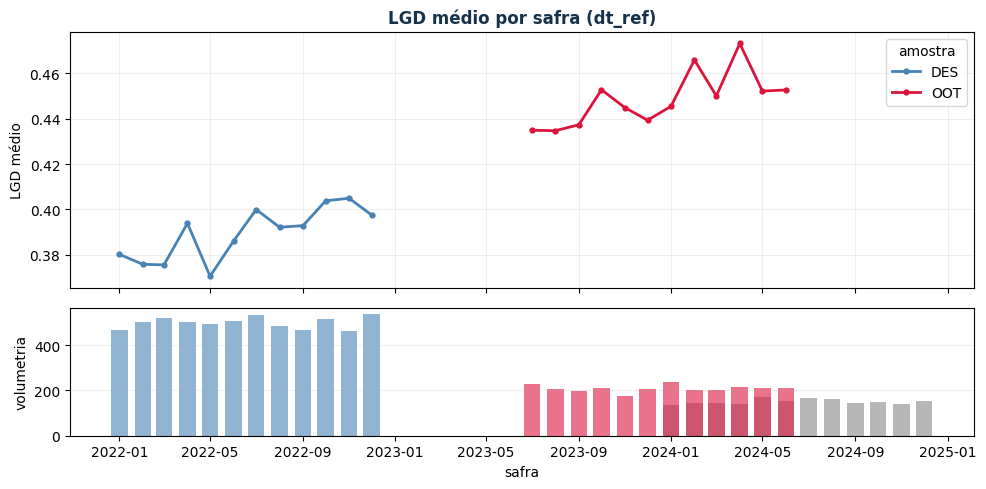

amostra,DES,ESTABILIDADE,OOT
ano,,,
2022,0.39,NaN,NaN
2023,NaN,NaN,0.441
2024,NaN,NaN,0.456


In [11]:
import matplotlib.pyplot as plt

# LGD médio e volumetria por safra (mês de dt_ref), por amostra
serie = (df.assign(safra=df['dt_ref'].dt.to_period('M').dt.to_timestamp())
           .groupby(['safra', 'amostra'], observed=True)
           .agg(lgd_medio=('lgd', 'mean'), n=('lgd', 'size'))
           .reset_index())

cores = {'DES': 'steelblue', 'OOT': 'crimson', 'ESTABILIDADE': '#888888'}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
for am, g in serie.groupby('amostra', observed=True):
    if g['lgd_medio'].notna().any():                 # ESTABILIDADE não tem LGD realizado
        ax1.plot(g['safra'], g['lgd_medio'], marker='o', ms=3.5, lw=2,
                 color=cores.get(am), label=am)
    ax2.bar(g['safra'], g['n'], width=22, color=cores.get(am), alpha=0.6, label=am)
ax1.set_title('LGD médio por safra (dt_ref)', fontweight='bold', color='#15324a')
ax1.set_ylabel('LGD médio'); ax1.grid(alpha=0.2); ax1.legend(title='amostra')
ax2.set_ylabel('volumetria'); ax2.set_xlabel('safra'); ax2.grid(axis='y', alpha=0.2)
fig.tight_layout(); plt.show()

# resumo: LGD médio por ANO e amostra — o LGD realizado sobe no tempo;
# ESTABILIDADE fica NaN (público recente, ainda sem target)
(df.assign(ano=df['dt_ref'].dt.year)
   .pivot_table(index='ano', columns='amostra', values='lgd', observed=True, dropna=False)
   .round(3))

## Instanciar e construir a árvore automática

In [12]:
seg = SequentialLGDSegmenter(
    df, target='lgd', sample_col='amostra', ref_sample='DES',
    date_col='dt_ref',     # coluna de safra: FORA da modelagem, só p/ análises no tempo
    feature_labels={'ltv':'LTV','dias_atraso':'dias em atraso','garantia':'garantia'},
)
seg.fit_auto(max_depth=3, min_iv=0.02)
seg.suggest_split('root')['msg']

[init] amostras: ['DES', 'OOT', 'ESTABILIDADE'] | referência PSI = DES
[fit_auto] árvore gulosa construída: profundidade 3 (máx +3), IV mínimo 0.02 → 8 folhas


"dividir por 'garantia' (IV=0.0746, médio)"

## Folhas finais (nota, LGD, representatividade e PSI)

In [13]:
seg.leaves(with_psi=True)

,segmento,nota_lgd,descricao,profundidade,n,repr_%,lgd_medio,lgd_std,lgd_DES,lgd_OOT,lgd_ESTABILIDADE,repr_DES_%,psi_OOT,repr_OOT_%,psi_ESTABILIDADE,repr_ESTABILIDADE_%
0,"dias_atraso: (-inf, 357.5] | garantia: {aliena...",1,dias em atraso até 357.5 e garantia em {aliena...,3,2403,23.3,0.2614,0.1387,0.2614,0.3176,NaN,23.0,0.0001,23.4,0.0007,24.3
1,"dias_atraso: (-inf, 357.5] | garantia: {aliena...",2,dias em atraso até 357.5 e garantia em {aliena...,3,1994,19.4,0.3785,0.1458,0.3785,0.4494,NaN,19.9,0.0001,19.6,0.0035,17.3
2,"dias_atraso: (-inf, 357.5] | garantia: {sem ga...",3,dias em atraso até 357.5 e garantia em {sem ga...,3,414,4.0,0.5096,0.1222,0.5096,0.5462,NaN,4.4,0.0015,3.6,0.0038,3.2
3,"dias_atraso: (-inf, 357.5] | garantia: {sem ga...",4,dias em atraso até 357.5 e garantia em {sem ga...,3,30,0.3,0.5147,0.0785,0.5147,0.5308,NaN,0.3,0.0000,0.3,0.0000,0.3
4,"dias_atraso: (-inf, 357.5] | garantia: {sem ga...",5,dias em atraso até 357.5 e garantia em {sem ga...,3,92,0.9,0.7431,0.0651,0.7431,0.7438,NaN,0.6,0.0059,1.4,0.0035,1.2
5,"dias_atraso: (357.5, inf] | garantia: {alienaç...",6,dias em atraso acima de 357.5 e garantia em {a...,3,2640,25.6,0.3585,0.1357,0.3585,0.4148,NaN,25.2,0.0003,26.0,0.0008,26.6
6,"dias_atraso: (357.5, inf] | garantia: {alienaç...",7,dias em atraso acima de 357.5 e garantia em {a...,3,2188,21.2,0.4780,0.1365,0.4780,0.5302,NaN,21.5,0.0012,19.9,0.0002,22.2
7,"dias_atraso: (357.5, inf] | garantia: {sem gar...",8,dias em atraso acima de 357.5 e garantia em {s...,2,539,5.2,0.6370,0.1362,0.6370,0.7086,NaN,5.1,0.0012,5.9,0.0001,4.8


## Análise de variáveis ao longo do tempo (safra `dt_ref`)
Com `date_col='dt_ref'` no segmenter, as análises temporais já sabem a coluna de safra. Para uma variável **numérica** (LTV): perfil, **PSI atual** por amostra e **PSI por safra** vs DES. Para uma variável **categórica** (garantia): **representatividade (%) de cada categoria por safra** — mostra a distribuição migrando no tempo. A amostra **ESTABILIDADE** (sem LGD) entra só no PSI.

In [14]:
# Como o seg foi criado com date_col='dt_ref', as análises no tempo dispensam passar a coluna.
# --- variável NUMÉRICA (LTV): perfil + PSI atual + PSI por safra ---
s = seg.variable_summary('ltv')
print(f"LTV — média {s['media']:.3f} · mediana {s['mediana']:.3f} · desvio {s['desvio']:.3f} "
      f"· %missing {s['pct_missing']:.1f}% · IV {s['iv']:.4f} ({s['forca']})")
print("PSI atual por amostra:", {a: round(v, 3) for a, v in s['psi'].items()})
display(seg.variable_psi_by_safra('ltv').tail(6))           # PSI de LTV por safra vs DES

# --- variável CATEGÓRICA (garantia): representatividade de cada categoria por safra ---
display(seg.variable_share_by_safra('garantia').tail(6))    # % de cada categoria por mês

LTV — média 0.976 · mediana 0.969 · desvio 0.272 · %missing 5.9% · IV 0.0617 (médio)
PSI atual por amostra: {'OOT': 0.28, 'ESTABILIDADE': 0.874}


,safra,n,psi,classificacao
24,2024-07,165,0.9491,instável
25,2024-08,161,1.4862,instável
26,2024-09,143,1.5647,instável
27,2024-10,147,2.3047,instável
28,2024-11,142,1.1215,instável
29,2024-12,152,1.2377,instável


garantia,safra,alienação,aval,fiança,sem garantia
24,2024-07,53.9,23.6,14.5,7.9
25,2024-08,46.0,24.8,19.3,9.9
26,2024-09,49.0,21.7,18.9,10.5
27,2024-10,52.4,21.1,17.7,8.8
28,2024-11,54.9,20.4,13.4,11.3
29,2024-12,48.7,23.0,19.1,9.2


## Árvore em texto

In [15]:
print(seg.tree())

TODA A CARTEIRA  (n=10300, 100.0%, LGD=0.4069)
├─ dias em atraso até 357.5  (n=4933, 47.9%, LGD=0.3582)
│  ├─ garantia em {alienação ou aval ou fiança}  (n=4397, 42.7%, LGD=0.3339)
│  │  ├─ garantia em {alienação}  (n=2403, 23.3%, LGD=0.2781)  [nota 1]
│  │  └─ garantia em {aval ou fiança}  (n=1994, 19.4%, LGD=0.3991)  [nota 2]
│  └─ garantia em {sem garantia}  (n=536, 5.2%, LGD=0.5542)
│     ├─ LTV até 1.3  (n=414, 4.0%, LGD=0.5190)  [nota 3]
│     ├─ LTV faltante  (n=30, 0.3%, LGD=0.5192)  [nota 4]
│     └─ LTV acima de 1.3  (n=92, 0.9%, LGD=0.7434)  [nota 5]
└─ dias em atraso acima de 357.5  (n=5367, 52.1%, LGD=0.4523)
   ├─ garantia em {alienação ou aval ou fiança}  (n=4828, 46.9%, LGD=0.4285)
   │  ├─ garantia em {alienação}  (n=2640, 25.6%, LGD=0.3755)  [nota 6]
   │  └─ garantia em {aval ou fiança}  (n=2188, 21.2%, LGD=0.4925)  [nota 7]
   └─ garantia em {sem garantia}  (n=539, 5.2%, LGD=0.6603)  [nota 8]

(8 folhas | profundidade máxima 3)
TODA A CARTEIRA  (n=10300, 100.0%, LGD

## Aplicar a régua em pandas (`predict`)
Repare que linhas com `ltv` faltante são roteadas para o segmento `(faltante)` — nada é descartado.

In [16]:
novos = gera(800)
pred = seg.predict(novos)
print('cobertura (linhas roteadas):', pred['segmento_lgd'].notna().mean())
pred.head()

cobertura (linhas roteadas): 1.0


,segmento_lgd,folha,lgd_regua
0,"dias_atraso: (-inf, 357.5] | garantia: {aliena...",1,0.261431
1,"dias_atraso: (357.5, inf] | garantia: {alienaç...",6,0.358537
2,"dias_atraso: (357.5, inf] | garantia: {alienaç...",6,0.358537
3,"dias_atraso: (357.5, inf] | garantia: {sem gar...",8,0.636968
4,"dias_atraso: (357.5, inf] | garantia: {alienaç...",7,0.477993


## Régua em PySpark (scoring em escala no Databricks)

In [17]:
print(seg.to_pyspark())

from pyspark.sql import functions as F

def aplicar_regua_lgd(df, col_seg='segmento_lgd', col_nota='folha', col_lgd='lgd_regua'):
    """Régua de LGD gerada por SequentialLGDSegmenter (segmento, folha e LGD)."""
    c1 = (F.col("dias_atraso") <= 357.5) & F.col("garantia").cast("string").isin('alienação', 'aval', 'fiança') & F.col("garantia").cast("string").isin('alienação')
    c2 = (F.col("dias_atraso") <= 357.5) & F.col("garantia").cast("string").isin('alienação', 'aval', 'fiança') & F.col("garantia").cast("string").isin('aval', 'fiança')
    c3 = (F.col("dias_atraso") <= 357.5) & F.col("garantia").cast("string").isin('sem garantia') & (F.col("ltv") <= 1.2999469637870789)
    c4 = (F.col("dias_atraso") <= 357.5) & F.col("garantia").cast("string").isin('sem garantia') & F.col("ltv").isNull()
    c5 = (F.col("dias_atraso") <= 357.5) & F.col("garantia").cast("string").isin('sem garantia') & (F.col("ltv") > 1.2999469637870789)
    c6 = (F.col("dias_atraso") > 357.5) & F.col("garantia").c

## Interface interativa — workbench em abas (opcional)

No Jupyter/Databricks, dá para construir e validar a árvore clicando. A interface é um **workbench em abas**:

- **① Construir** — cockpit de 3 painéis: à esquerda *qual variável segmentar* (IV contínuo do optbinning + PSI por variável, nos **mesmos bins**) e o histograma de LGD da folha; ao centro o cabeçalho da folha, a árvore e o preview da divisão; à direita as ações, o assistente e a poda. O **Auto-fit** com uma folha selecionada cresce só aquela folha; ao final há um **preview da árvore** em imagem.
- **② Análise de variável** — distribuição, %missing, média/mediana/desvio, faixa de percentis, **PSI atual** e o comportamento por **safra**: numérica → percentis por safra; categórica → **representatividade de cada categoria por safra**.
- **③ Diagnóstico** — folhas (PSI por amostra e teste de hipótese), métricas R² da régua, IC bootstrap e dispersão.
- **④ Validar & Exportar** — monotonicidade, calibração, backtest, exportar `ui.result`, MLflow e Spark.
- **⑤ Histórico** — salvar/carregar a árvore em JSON e a imagem da árvore.

Passe `date_col='dt_ref'` para as análises no tempo. A amostra **ESTABILIDADE** (sem LGD) entra só no **PSI**, não nas médias de LGD nem nas métricas.

```python
from yggdrasil.credit_risk.lgd import LGDSegmenterUI
ui = LGDSegmenterUI(df, target='lgd', sample_col='amostra', ref_sample='DES',
                    date_col='dt_ref',                 # safra p/ as análises no tempo
                    feature_labels={'ltv':'LTV','dias_atraso':'dias em atraso','garantia':'garantia'},
                    tree_samples=['DES','OOT'])         # LGD na árvore (ESTABILIDADE só no PSI)
ui
```

## Registrar no MLflow / Unity Catalog
```python
seg.log_to_mlflow(registered_model_name='catalogo.schema.lgd_segmentacao',
                  registry_uri='databricks-uc')
```

In [ ]:
from yggdrasil.credit_risk.lgd import LGDSegmenterUI
ui = LGDSegmenterUI(df, target='lgd', sample_col='amostra', ref_sample='DES',
                    date_col='dt_ref',                 # safra p/ as análises no tempo
                    feature_labels={'ltv':'LTV','dias_atraso':'dias em atraso','garantia':'garantia'},
                    tree_samples=['DES','OOT'])         # LGD na árvore (ESTABILIDADE só no PSI)
ui